In [7]:
%pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 78 kB 2.1 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import requests
import pandas as pd
import os
import time
import mercantile
from PIL import Image
from io import BytesIO

# --- CONFIGURATION ---
# The fire started Jan 7, 2025. We want the latest map BEFORE this date.
FIRE_DATE = pd.to_datetime("2025-01-07") 

# Paths
INPUT_CSV = "../data/processed/clean_homes.csv"
OUTPUT_DIR = "../data/images"
if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)

# Esri Wayback Catalog URL
WAYBACK_CONFIG_URL = "https://s3-us-west-2.amazonaws.com/config.maptiles.arcgis.com/waybackconfig.json"

print("Configuration loaded.")

/Users/tejusagrawal/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Configuration loaded.


In [4]:
import re

# Updated Chunk 2: Robust Wayback Fetcher (Regex Edition)
def get_best_prefire_layer():
    print("Fetching Wayback Catalog...")
    try:
        r = requests.get(WAYBACK_CONFIG_URL, timeout=15)
        r.raise_for_status()
        data = r.json()
    except Exception as e:
        raise Exception(f"Failed to connect to Esri: {e}")
    
    versions = []
    # Regex to find "Wayback 2024-01-01" in the title
    date_pattern = re.compile(r"Wayback (\d{4}-\d{2}-\d{2})")
    
    for key, val in data.items():
        # 1. Try explicit keys first (legacy support)
        date_str = val.get('releaseDatme') or val.get('releaseDate')
        
        # 2. Fallback: Extract from Title (e.g., "World Imagery (Wayback 2021-02-20)")
        if not date_str and 'itemTitle' in val:
            match = date_pattern.search(val['itemTitle'])
            if match:
                date_str = match.group(1)
        
        if date_str:
            versions.append({
                'id': key,
                'date': pd.to_datetime(date_str),
                'url_template': val['itemURL']
            })
            
    if not versions:
        # Debugging: Print one item to see what went wrong
        first_key = list(data.keys())[0]
        print(f"DEBUG Sample: {data[first_key]}")
        raise Exception("Could not extract dates. Pattern match failed.")
        
    df_v = pd.DataFrame(versions)
    
    # Filter: Strictly BEFORE the fire
    fire_ts = pd.to_datetime(FIRE_DATE)
    pre_fire = df_v[df_v['date'] < fire_ts].sort_values('date', ascending=False)
    
    if pre_fire.empty:
        raise Exception(f"No maps found before {FIRE_DATE}.")
        
    best_layer = pre_fire.iloc[0]
    print(f"✅ Selected Vintage: {best_layer['date'].date()} (ID: {best_layer['id']})")
    
    # Construct the Direct Tile URL Template
    # We strip the '/item.html' to get the tile base
    base_url = "https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/MapServer/tile"
    final_url_template = f"{base_url}/{best_layer['id']}/{{z}}/{{y}}/{{x}}"
    
    return final_url_template

# Execute
tile_url_template = get_best_prefire_layer()
print(f"Template: {tile_url_template}")

Fetching Wayback Catalog...
✅ Selected Vintage: 2024-12-12 (ID: 16453)
Template: https://wayback.maptiles.arcgis.com/arcgis/rest/services/World_Imagery/MapServer/tile/16453/{z}/{y}/{x}


In [13]:
def download_stitched_home(lat, lon, layer_url, zoom=20):
    
    # 1. Fetch 3x3 Grid (Source Data)
    def fetch_grid(target_zoom):
        center_tile = mercantile.tile(lon, lat, target_zoom)
        stitched = Image.new('RGB', (256*3, 256*3))
        tiles_found = 0
        
        for i, dx in enumerate([-1, 0, 1]):
            for j, dy in enumerate([-1, 0, 1]):
                tile = mercantile.Tile(center_tile.x + dx, center_tile.y + dy, target_zoom)
                url = layer_url.format(z=target_zoom, y=tile.y, x=tile.x)
                
                try:
                    r = requests.get(url, timeout=3)
                    if r.status_code == 200:
                        tile_img = Image.open(BytesIO(r.content))
                        stitched.paste(tile_img, (i*256, j*256))
                        tiles_found += 1
                except:
                    pass
        return stitched, tiles_found

    # Try Zoom 20 first (Max Detail). Fallback to 19.
    img, count = fetch_grid(zoom)
    if count < 5 and zoom > 18:
        img, count = fetch_grid(zoom - 1)

    # 2. The "Sweet Spot" Crop
    # -------------------------
    # 250 = Too zoomed in (Blurry)
    # 640 = Too zoomed out (House is tiny)
    # 450 = Balanced (Sharp house + defensible space context)
    crop_size = 450 
    
    half = crop_size // 2
    # Center of 768x768 canvas is (384, 384)
    left = 384 - half
    top = 384 - half
    right = 384 + half
    bottom = 384 + half
    
    tight_crop = img.crop((left, top, right, bottom))
    
    # Resize to 640x640 (Standard input for Neural Nets)
    # LANCZOS filter keeps lines sharp during resize
    final_img = tight_crop.resize((640, 640), Image.Resampling.LANCZOS)
    
    return final_img

Matplotlib is building the font cache; this may take a moment.


Testing Crop 450px (Sharper) on these addresses:


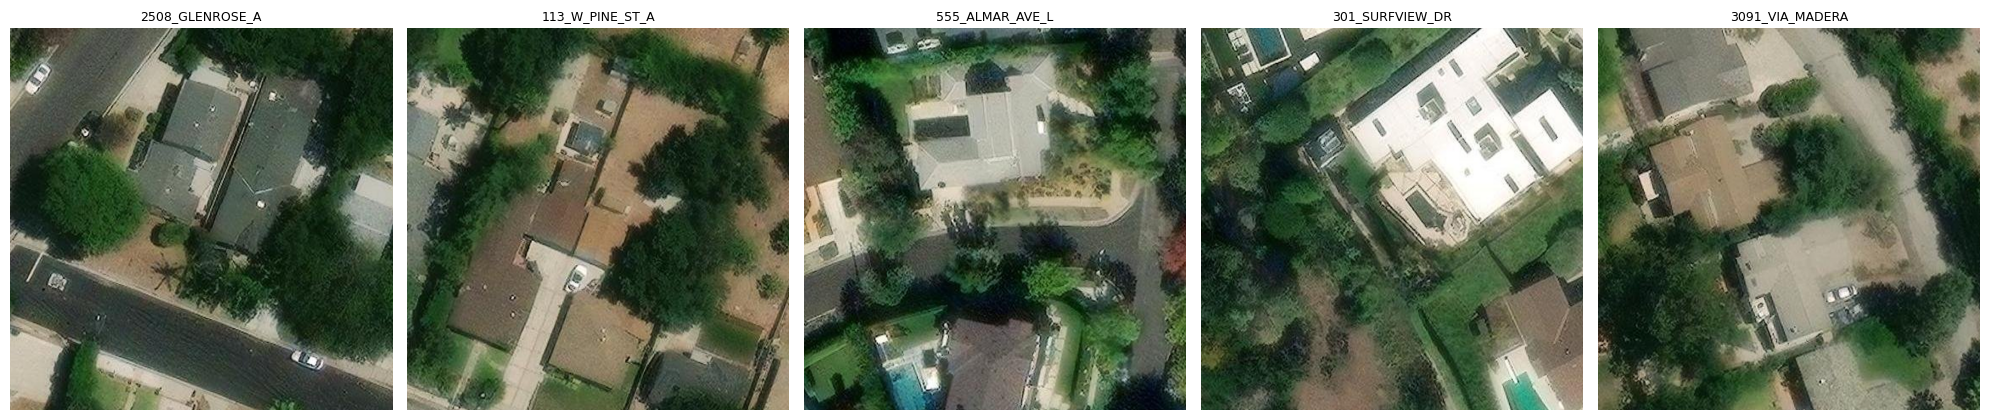

In [14]:
# Test Visualization Block
import matplotlib.pyplot as plt

TEST_DIR = "../data/test_zoom_samples"
if not os.path.exists(TEST_DIR): os.makedirs(TEST_DIR)

# Pick 5 random homes
test_df = df.sample(5) 

print(f"Testing Crop 450px (Sharper) on these addresses:")

plt.figure(figsize=(20, 10))

for i, (index, row) in enumerate(test_df.iterrows()):
    try:
        fname_str = row['filename'] if pd.notna(row['filename']) else str(row['id'])
        
        # Run the updated function
        img = download_stitched_home(row['lat'], row['lon'], tile_url_template, zoom=20)
        
        # Save & Show
        img.save(f"{TEST_DIR}/{fname_str}.jpg")
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(fname_str[:15], fontsize=9)
        plt.axis('off')
        
    except Exception as e:
        print(f"Error: {e}")

plt.tight_layout()
plt.show()

In [16]:
import concurrent.futures
from tqdm import tqdm

MAX_WORKERS = 20
INPUT_CSV = "../data/processed/clean_homes.csv"
OUTPUT_DIR = "../data/images"

df = pd.read_csv(INPUT_CSV)
print(f"Queueing up {len(df)} homes...")

def process_one_home(row):
    try:
        # USE ADDRESS FOR FILENAME
        # Fallback to ID if filename is missing
        fname_str = row['filename'] if pd.notna(row['filename']) else str(row['id'])
        save_path = f"{OUTPUT_DIR}/{fname_str}.jpg"
        
        if os.path.exists(save_path):
            return "Skipped"
            
        img = download_stitched_home(row['lat'], row['lon'], tile_url_template, zoom=20)
        
        # Check if we got a valid image (not all black/white)
        extrema = img.convert("L").getextrema()
        if extrema == (0, 0) or extrema == (255, 255):
             return "Blank"

        img.save(save_path)
        return "Success"
            
    except Exception as e:
        return f"Error: {e}"

rows = df.to_dict('records')

with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    results = list(tqdm(executor.map(process_one_home, rows), total=len(rows), unit="img"))

print("-" * 30)
print(f"Success: {results.count('Success')}")
print(f"Skipped: {results.count('Skipped')}")
print(f"Errors/Blank: {len(rows) - results.count('Success') - results.count('Skipped')}")

Queueing up 21361 homes...


100%|██████████| 21361/21361 [2:18:27<00:00,  2.57img/s]   

------------------------------
Success: 21163
Skipped: 198
Errors/Blank: 0
